In [12]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns


sns.set()

Here we will statistically prove that the LMSYS dataset has specific properties(redundancy and clustering) that makes semantic caching a vialbe stratergy,

In [43]:
CACHE_PATH = "../data/embeddings/train_data.npy"  # Shape: (437701, 384)
TEST_PATH = "../data/embeddings/test_data.npy"    # Shape: (136782, 384)
OUTPUT_DIR = "../results/characterization"

DIMENSION = 384
THRESHOLD_STRICT = 0.85
NUM_CLUSTERS = 100 # For K-Means Clustering

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Checking for Redundancy

In [31]:
def analyze_redundancy(cache_emb, test_emb):
    '''
    This function helps us proove REDUNDANCY: This means that the queries that are asked by the user do repeat
    themselves.
    '''
    print("Building FAISS Index (IndexFlatIP for Cosine Similarity)...")
    # IP = Inner Product. If vectors are normalized, IP == Cosine Similarity.
    index = faiss.IndexFlatIP(DIMENSION)
    
    # Load cache into RAM (approx 700MB)
    index.add(np.ascontiguousarray(cache_emb, dtype='float32'))
    
    print(f"Searching {test_emb.shape[0]} test queries...")
    test_data = np.ascontiguousarray(test_emb, dtype='float32')
    
    # Find the SINGLE best match (k=1) for every query
    # D will contain Similarity Scores (e.g., 0.92, 0.85)
    D, I = index.search(test_data, k=1)
    
    return D.flatten()

In [30]:
def load_data():
    print(f"Loading Cache (Train) from {CACHE_PATH}...")
    cache_emb = np.load(CACHE_PATH, mmap_mode='r')
    
    print(f"Loading Queries (Test) from {TEST_PATH}...")
    test_emb = np.load(TEST_PATH, mmap_mode='r')
    return cache_emb, test_emb

In [35]:
def plot_and_save(similarities):
    print("Plotting histogram...")
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of Similarity Scores
    plt.hist(similarities, bins=100, range=(0, 1), 
             color='blue', alpha=0.7, 
             label='Similarity Score')
    
    plt.axvline(THRESHOLD_STRICT, color='red', linestyle='--', linewidth=2, label='Cache Hit Threshold (0.85)')
    
    plt.title("Workload Characterization: Semantic Redundancy")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Number of Queries (Log Scale)")
    plt.yscale('log') # Log scale is crucial to see the small "hit" spikes
    plt.legend()
    plt.grid(True)
    
    outfile = os.path.join(OUTPUT_DIR, "redundancy_distribution.png")
    plt.savefig(outfile)
    print(f"Plot saved to: {outfile}")
    
    # Save Stats
    hit_rate = np.mean(similarities > THRESHOLD_STRICT)
    print(f"\n--- PAPER STATS ---")
    print(f"Avg Similarity: {np.mean(similarities):.4f}")
    print(f"Projected Cache Hit Rate (>0.85): {hit_rate*100:.2f}%")
    
    with open(os.path.join(OUTPUT_DIR, "redundancy_stats.json"), "w") as f:
        json.dump({"hit_rate_0.85": hit_rate, "mean_sim": float(np.mean(similarities))}, f)

Loading Cache (Train) from ../data/embeddings/train_data.npy...
Loading Queries (Test) from ../data/embeddings/test_data.npy...
Building FAISS Index (IndexFlatIP for Cosine Similarity)...
Searching 136782 test queries...
Plotting histogram...
Plot saved to: ../results/characterization/redundancy_distribution.png

--- PAPER STATS ---
Avg Similarity: 0.8786
Projected Cache Hit Rate (>0.85): 68.54%


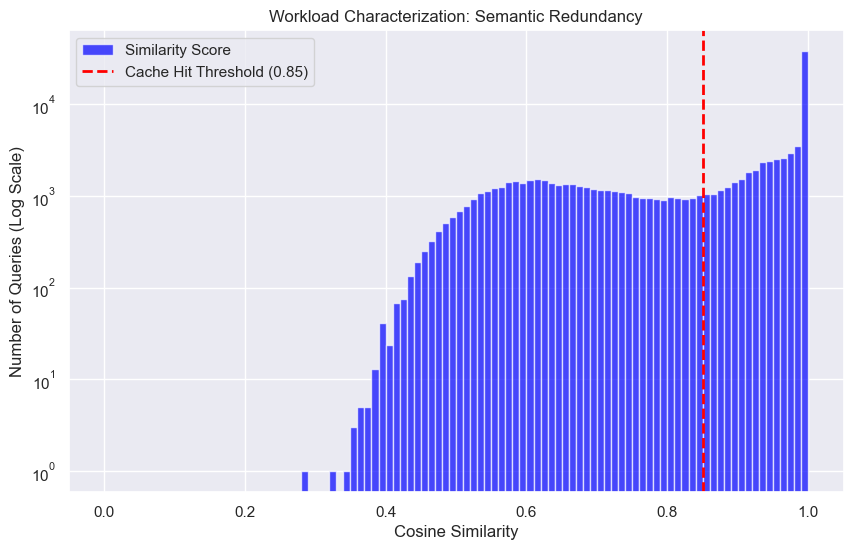

In [36]:
cache,test = load_data()
sims = analyze_redundancy(cache,test)
plot_and_save(sims)

# Checking Skewness

In [37]:
def compute_gini(array:np.ndarray) -> np.ndarray:
    '''This function helps in calculating the gini-index'''
    mad = np.abs(np.subtract.outer(array,array)).mean()
    rmad = mad / np.mean(array)
    gini = 0.5 * rmad
    return gini

In [38]:
def run_clustering_analysis(train_data):
    # print(f"Loading Cache (Train) from {CACHE_PATH}...")
    # Load data
    data = train_data
    d = data.shape[1]
    
    # FAISS K-Means is much faster than Scikit-Learn for large datasets
    print(f"Running K-Means (k={NUM_CLUSTERS}) on {data.shape[0]} vectors...")
    kmeans = faiss.Kmeans(d, NUM_CLUSTERS, niter=20, verbose=True, seed=42)
    kmeans.train(data.astype('float32'))
    
    # Assign every query to a cluster
    print("Assigning queries to clusters...")
    D, I = kmeans.index.search(data.astype('float32'), 1)
    cluster_assignments = I.flatten()
    
    # Count size of each cluster
    cluster_sizes = np.bincount(cluster_assignments, minlength=NUM_CLUSTERS)
    
    # Sort for visualization
    sorted_sizes = np.sort(cluster_sizes)[::-1] # Descending
    
    return sorted_sizes

In [39]:
def plot_lorenz_curve(cluster_sizes):
    """
    Plots the Lorenz curve to visualize inequality (clustering).
    """
    print("Plotting Lorenz Curve...")
    n = len(cluster_sizes)
    # Sort small to large for Lorenz
    sorted_asc = np.sort(cluster_sizes)
    
    # Cumulative sums
    cum_clusters = np.arange(1, n + 1) / n
    cum_queries = np.cumsum(sorted_asc) / np.sum(sorted_asc)
    
    plt.figure(figsize=(8, 8))
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality (Gini=0)')
    plt.plot(cum_clusters, cum_queries, color='blue', linewidth=2, label='Actual Distribution')
    
    plt.title("Lorenz Curve: Query Distribution Across Topics")
    plt.xlabel("Cumulative % of Clusters (Topics)")
    plt.ylabel("Cumulative % of Queries")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    outfile = os.path.join(OUTPUT_DIR, "clustering_lorenz_curve.png")
    plt.savefig(outfile)
    print(f"Saved plot: {outfile}")

In [40]:
def plot_cluster_sizes(sorted_sizes):
    print("Plotting Cluster Size Distribution...")
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(sorted_sizes)), sorted_sizes, color='purple', alpha=0.7)
    plt.title(f"Size of Top {len(sorted_sizes)} Semantic Clusters")
    plt.xlabel("Cluster ID (Sorted by Size)")
    plt.ylabel("Number of Queries")
    plt.grid(axis='y', alpha=0.3)
    
    outfile = os.path.join(OUTPUT_DIR, "clustering_histogram.png")
    plt.savefig(outfile)
    print(f"Saved plot: {outfile}")

In [41]:
def main():
    cluster_sizes = run_clustering_analysis(train_data)
    
    # Compute Stats
    gini = compute_gini(cluster_sizes)
    top_10_percent_share = np.sum(cluster_sizes[:10]) / np.sum(cluster_sizes)
    
    print("\n--- RESULTS FOR PAPER ---")
    print(f"Gini Coefficient: {gini:.4f}")
    print(f"Top 10 Clusters hold {top_10_percent_share*100:.1f}% of all queries")
    
    # Save Stats
    stats = {
        "gini_coefficient": float(gini),
        "top_10_clusters_share": float(top_10_percent_share),
        "num_clusters": NUM_CLUSTERS
    }
    with open(os.path.join(OUTPUT_DIR, "clustering_stats.json"), "w") as f:
        json.dump(stats, f, indent=4)
        
    # Plot
    plot_lorenz_curve(cluster_sizes)
    plot_cluster_sizes(cluster_sizes)

Running K-Means (k=100) on 437701 vectors...
Sampling a subset of 25600 / 437701 for training
Clustering 25600 points in 384D to 100 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.09 s
Assigning queries to clusters....09 s): objective=16937.3 imbalance=1.290 nsplit=0       

--- RESULTS FOR PAPER ---
Gini Coefficient: 0.2622
Top 10 Clusters hold 21.6% of all queries
Plotting Lorenz Curve...
Saved plot: ../results/characterization/clustering_lorenz_curve.png
Plotting Cluster Size Distribution...
Saved plot: ../results/characterization/clustering_histogram.png


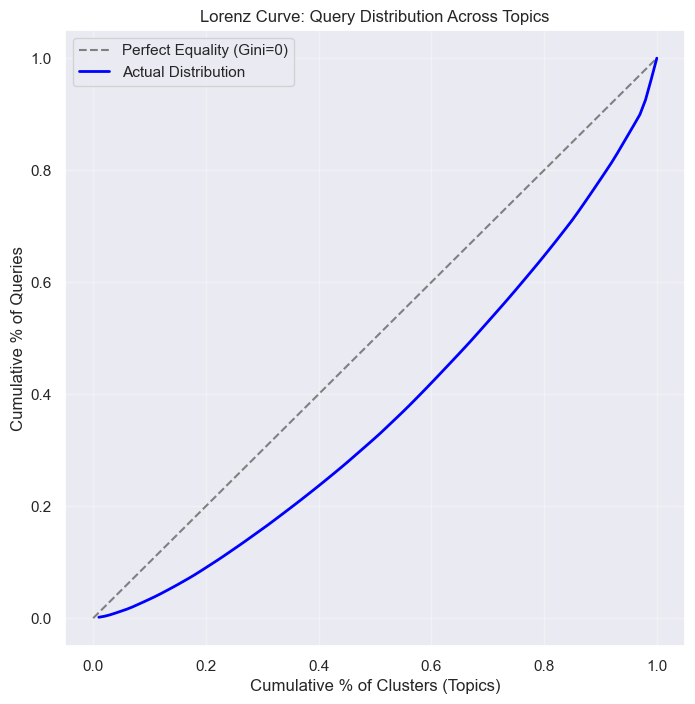

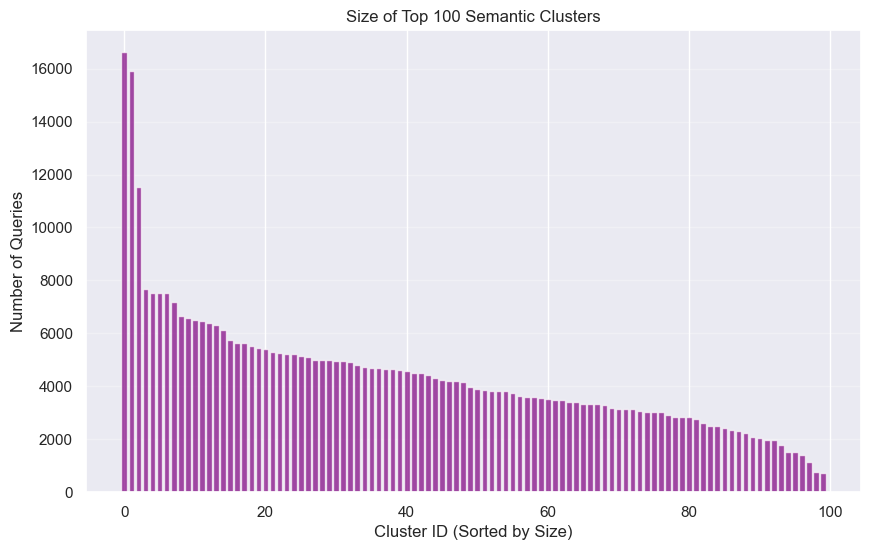

In [44]:
main()